In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "15"
os.environ["OPENBLAS_NUM_THREADS"] = "15"
import numpy as np
import scipy.sparse as sp
from scipy.special import genlaguerre, gammaln, lpmv


# ---------------------------------------------------------------------------
# Primitive sparse local operators
# ---------------------------------------------------------------------------

def _eye(d):
    return sp.eye(d, format='csr')

def _destroy(d):
    data = np.sqrt(np.arange(1, d, dtype=float))
    return sp.diags(data, 1, shape=(d, d), format='csr')

def _num(d):
    return sp.diags(np.arange(d, dtype=float), 0, format='csr')


def sparse_embed(ops_at_indices: dict, n_total: int, fock_dim: int) -> sp.csr_matrix:
    """
    Same semantics as your QuTiP embed(), but returns a scipy sparse matrix.
    ops_at_indices: {site_index: sparse_matrix}
    """
    local_ops = [_eye(fock_dim)] * n_total
    for idx, op in ops_at_indices.items():
        local_ops[idx] = op

    result = local_ops[0]
    for op in local_ops[1:]:
        result = sp.kron(result, op, format='csr')
    return result


def squeeze_matrix_element_legendre(r, m, n):

    if (m - n) % 2 != 0:
        return 0.0

    x = 1.0 / np.cosh(r)
    l = (m + n) / 2  # half-integer in general, but integer when m+n even
    n_less = min(m, n)
    n_greater = max(m, n)

    log_prefactor = 0.5 * (gammaln(n_less + 1) - gammaln(n_greater + 1))

    if m >= n:
        # Eq. (8): k = (m-n)/2
        k = (m - n) // 2
        sign = (-1) ** k
        P = lpmv(k, l, x)
        return sign * np.exp(log_prefactor) * np.sqrt(x) * P

    else:
        # Eq. (9): k' = (n-m)/2
        k = (n - m) // 2
        P = lpmv(k, l, x)
        return np.exp(log_prefactor) * np.sqrt(x) * P

def minimum_n(Omega_C, n, threshold = 0.99, N = 60):
    r = -0.25 * np.log(1-Omega_C)
    prob_array = [squeeze_matrix_element_legendre(r, i, n)**2 for i in range(N)]
    sum = 0.0 
    for j, prob in enumerate(prob_array):
        sum += prob
        if sum >= threshold:
            return j+1
    
    return N 
   
def capacitive_ssh_sparse(N, chi_C, Omega_C, energy_level = 1):
    g1 = 0.5 * Omega_C * (1 + chi_C)
    g2 = 0.5 * Omega_C * (1 - chi_C)
    fock_transmon = minimum_n(Omega_C, energy_level)
    
    b_op = _destroy(fock_transmon)
    bd_op = b_op.T.conj()
    n_op = _num(fock_transmon)
    n_sites = 2 * N
    dim = fock_transmon ** n_sites
    
    H = sp.csr_matrix((dim, dim), dtype=complex)
    
    
    for j in range(N):
        # --- diagonal ---
        H += sparse_embed({2 * j:     n_op}, n_sites, fock_transmon)
        H += sparse_embed({2 * j + 1: n_op}, n_sites, fock_transmon)
        
        # --- hopping  b†_{A,j} b_{B,j}  +  h.c. ---
        op_hop1 = sparse_embed({2 * j: bd_op, 2 * j + 1: b_op}, n_sites, fock_transmon)
        H += g1 * op_hop1
        H += g1 * op_hop1.conj().T
        
        # --- hopping  b†_{A,j} b_{B,j}  +  h.c. ---
        if j != N-1:
            op_hop2 = sparse_embed({2 * j + 1: bd_op, 2 * j + 2: b_op}, n_sites, fock_transmon)
            H += g2 * op_hop2
            H += g2 * op_hop2.conj().T
            
        op_pairing1 = sparse_embed({2 * j: bd_op, 2 * j + 1: bd_op}, n_sites, fock_transmon)
        H -= g1 * op_pairing1
        H -= g1 * op_pairing1.conj().T
        
        if j != N-1:
            op_pairing2 = sparse_embed({2 * j + 1: bd_op, 2 * j + 2: bd_op}, n_sites, fock_transmon)
            H -= g2 * op_pairing2
            H -= g2 * op_pairing2.conj().T
            
    
    return H
    

In [ ]:
Omega_C = 0.3
chi_C_values = np.linspace(-1.0, 1.0, 15)
N = 4
energies = []
for chi_C in chi_C_values:
    H = capacitive_ssh_sparse(N, chi_C, Omega_C)
    energies.append(sp.linalg.eigsh(H, k = 2 * N + 1, which = 'SA', return_eigenvectors = False))

energies = np.array(energies)

In [6]:
import matplotlib.pyplot as plt 
import scienceplots 
plt.style.use(['science', 'no-latex', 'notebook'])

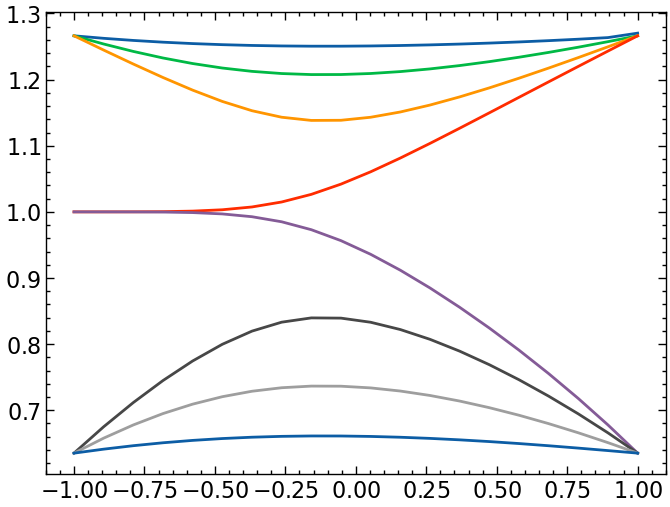

In [19]:
plt.plot(chi_C_values, ((energies.T - energies.T[-1])[:-1]).T)

In [21]:
Omega_C = 0.7
chi_C_values = np.linspace(-1.0, 1.0, 15)
N = 3
energies = []
for chi_C in chi_C_values:
    H = capacitive_ssh_sparse(N, chi_C, Omega_C)
    energies.append(sp.linalg.eigsh(H, k = 2 * N + 1, which = 'SA', return_eigenvectors = False))

energies = np.array(energies)

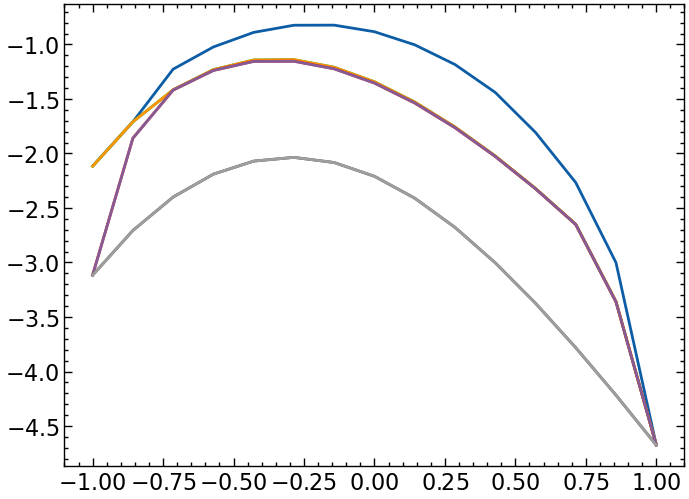

In [23]:
plt.plot(chi_C_values, energies)